In [3]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
from collections import Counter
from PIL import Image

BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 1e-4
IMG_SIZE = 224
SEED = 42

base_search_dir = "/kaggle/input" if os.path.exists("/kaggle/input") else "./"

all_image_paths = glob.glob(os.path.join(base_search_dir, "**", "*.*"), recursive=True)
all_image_paths = [f for f in all_image_paths if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]

if len(all_image_paths) == 0:
    raise ValueError(f"CRITICAL ERROR: No images found anywhere inside {base_search_dir}!")

discovered_classes = set()
for f in all_image_paths:
    parent_folder = os.path.basename(os.path.dirname(f))
    if parent_folder.lower() not in ['training', 'testing', 'train', 'test', 'val']:
        discovered_classes.add(parent_folder)

CLASSES = sorted(list(discovered_classes))
print(f"Automatically discovered {len(CLASSES)} classes: {CLASSES}")

class_to_idx = {cls_name: i for i, cls_name in enumerate(CLASSES)}

all_files = []
all_labels = []

for f in all_image_paths:
    parent_folder = os.path.basename(os.path.dirname(f))
    if parent_folder in class_to_idx:
        all_files.append(f)
        all_labels.append(class_to_idx[parent_folder])

print(f"Successfully loaded {len(all_files)} images.")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

torch.manual_seed(SEED)
np.random.seed(SEED)


Automatically discovered 4 classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Successfully loaded 17813 images.
Using device: cuda


In [4]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15), 
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class BrainTumorDataset(Dataset):
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        img_path = self.file_paths[idx]
        image = Image.open(img_path).convert("RGB")
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

class_counts = Counter(all_labels)
class_weights = []
for i in range(len(CLASSES)):
    count = class_counts.get(i, 0)
    weight = len(all_labels) / count if count > 0 else 1.0 # Protect against zero div
    class_weights.append(weight)

weights_tensor = torch.FloatTensor(class_weights).to(device)

X_train, X_val, y_train, y_val = train_test_split(all_files, all_labels, test_size=0.2, random_state=SEED, stratify=all_labels)

train_dataset = BrainTumorDataset(X_train, y_train, transform=train_transforms)
val_dataset = BrainTumorDataset(X_val, y_val, transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


In [14]:
class BrainTumorClassifier(nn.Module):
    def __init__(self, num_classes=4):
        super(BrainTumorClassifier, self).__init__()
        weights = models.ResNet50_Weights.DEFAULT
        self.base_model = models.resnet50(weights=weights)
        
        num_ftrs = self.base_model.fc.in_features
        self.base_model.fc = nn.Sequential(
            nn.Dropout(0.5), # Regularization
            nn.Linear(num_ftrs, num_classes)
        )
        
    def forward(self, x):
        return self.base_model(x)

model = BrainTumorClassifier(num_classes=len(CLASSES)).to(device)
print("ResNet50 Model initialized!")

criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)


ResNet50 Model initialized!


In [ ]:
best_f1 = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    # Train
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
    
    epoch_loss = running_loss / len(train_dataset)
    
    # Evaluate
    model.eval()
    val_loss = 0.0
    all_preds, all_targets = [], []
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            
            val_loss += criterion(outputs, labels).item() * inputs.size(0)
            
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())
            
    val_loss = val_loss / len(val_dataset)
    
    # Metrics calculation
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average='macro') 
    precision = precision_score(all_targets, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_targets, all_preds, average='macro')
    
    scheduler.step(val_loss)
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"--> Accuracy: {acc:.4f} | F1 Score: {f1:.4f} (Precision: {precision:.4f}, Recall: {recall:.4f})")
    
    # Save the highest F1-Score model
    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), "/kaggle/working/best_tumor_model.pth")

print("Training cycle completed.")


Epoch 1/20 | Train Loss: 0.5243 | Val Loss: 0.4075
--> Accuracy: 0.8215 | F1 Score: 0.8305 (Precision: 0.8305, Recall: 0.8369)
Epoch 2/20 | Train Loss: 0.3734 | Val Loss: 0.3552
--> Accuracy: 0.8417 | F1 Score: 0.8491 (Precision: 0.8469, Recall: 0.8536)
Epoch 3/20 | Train Loss: 0.3265 | Val Loss: 0.4018
--> Accuracy: 0.8134 | F1 Score: 0.8226 (Precision: 0.8224, Recall: 0.8299)
Epoch 4/20 | Train Loss: 0.2935 | Val Loss: 0.3223
--> Accuracy: 0.8319 | F1 Score: 0.8393 (Precision: 0.8395, Recall: 0.8517)


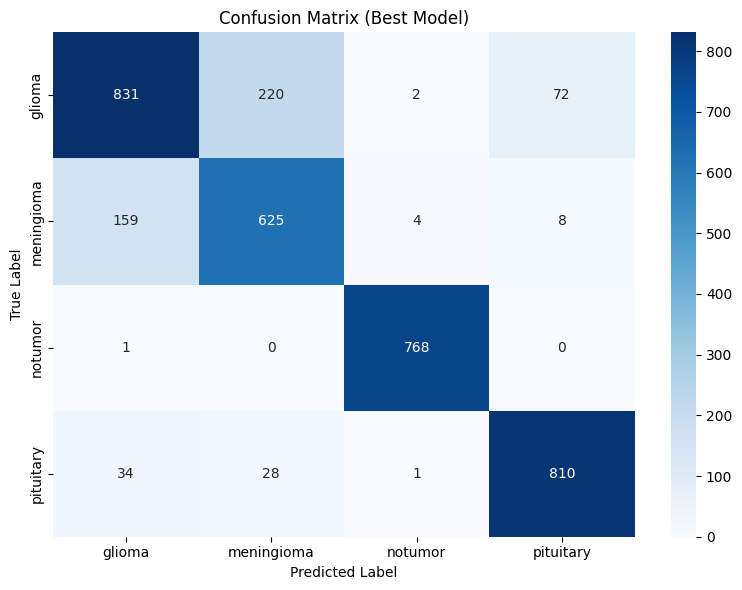

In [8]:

if os.path.exists("/kaggle/working/best_tumor_model.pth"):
    model.load_state_dict(torch.load("/kaggle/working/best_tumor_model.pth", map_location=device))
model.eval()

y_true, y_pred = [], []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title("Confusion Matrix (Best Model)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show() 


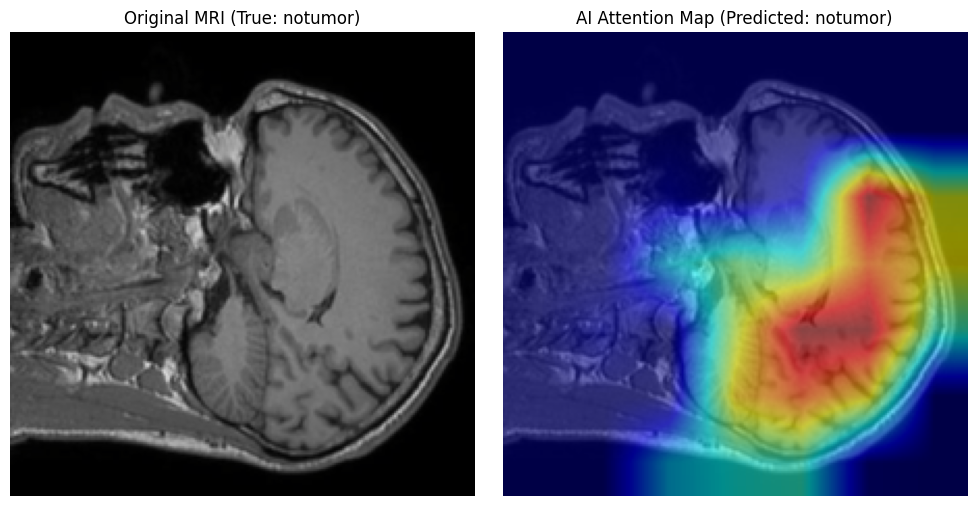

In [17]:
import cv2

class GradCam:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, x, target_class=None):
        self.model.eval()
        self.model.zero_grad()
        output = self.model(x)
        
        if target_class is None:
            target_class = output.argmax(dim=1).item()
            
        score = output[0, target_class]
        score.backward()
        
        gradients = self.gradients[0].cpu().data.numpy()
        activations = self.activations[0].cpu().data.numpy()
        weights = np.mean(gradients, axis=(1, 2))
        
        cam = np.zeros(activations.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            cam += w * activations[i]
            
        cam = np.maximum(cam, 0)
        cam = cv2.resize(cam, (x.shape[3], x.shape[2]))
        cam = cam - np.min(cam)
        cam = cam / np.max(cam)
        return cam, target_class


model.eval()
sample_inputs, sample_labels = next(iter(val_loader))
sample_input = sample_inputs[0:1].to(device)
true_label = CLASSES[sample_labels[0].item()]


target_layer = model.base_model.layer4[-1].conv3


cam_generator = GradCam(model, target_layer)
cam, pred_class = cam_generator(sample_input)


img = sample_inputs[0].permute(1, 2, 0).cpu().numpy()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img = std * img + mean
img = np.clip(img, 0, 1)

heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
heatmap = np.float32(heatmap) / 255
heatmap = heatmap[..., ::-1] # BGR to RGB

cam_img = heatmap + img
cam_img = cam_img / np.max(cam_img)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title(f"Original MRI (True: {true_label})")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cam_img)
plt.title(f"AI Attention Map (Predicted: {CLASSES[pred_class]})")
plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

# 1. Load the trained weights
model.load_state_dict(torch.load("best_tumor_model.pth", map_location=device))
model.eval()

# 2. Get predictions
all_p, all_t = [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        out = model(inputs.to(device))
        all_p.extend(out.argmax(1).cpu().numpy())
        all_t.extend(labels.numpy())

# 3. Print only the requested metrics
print(f"Final Accuracy: {accuracy_score(all_t, all_p):.4f}")
print(f"Final F1-Score: {f1_score(all_t, all_p, average='macro'):.4f}")
